In [1]:
from gentropy.common.session import Session


app_name = "example_app"
CREDENTIALS = "/Users/ss60/.config/gcloud/service_account_credentials.json"

# GCS Connector configuration
GCS_CONNECTOR_CONF = {
    "spark.hadoop.fs.gs.impl": "com.google.cloud.hadoop.fs.gcs.GoogleHadoopFileSystem",
    "spark.jars": "https://storage.googleapis.com/hadoop-lib/gcs/gcs-connector-hadoop3-latest.jar",
    "spark.hadoop.google.cloud.auth.service.account.enable": "true",
    "spark.hadoop.google.cloud.auth.service.account.json.keyfile": CREDENTIALS,
    "spark.hadoop.fs.gs.requester.pays.mode": "AUTO",  # Change to CUSTOM, ENABLED, or DISABLED as needed
    "spark.hadoop.fs.gs.requester.pays.project.id": "open-targets-genetics-dev",
}

# Extended Spark configuration
extended_spark_conf = {
    "spark.driver.memory": "12g",
    "spark.kryoserializer.buffer.max": "500m",
    "spark.driver.maxResultSize": "3g",
}

# Combine configurations
combined_conf = {**GCS_CONNECTOR_CONF, **extended_spark_conf}

# Start the session
session = Session(
    spark_uri="local[*]",  # Use appropriate URI if needed
    app_name=app_name,
    extended_spark_conf=combined_conf,
)

Loading BokehJS ...

/Users/ss60/Projects/Gentropy-manuscript/.venv/lib/python3.11/site-packages/pyspark/sql/pandas/functions.py:407: UserWarning:

In Python 3.6+ and Spark 3.0+, it is preferred to specify type hints for pandas UDF instead of specifying pandas UDF type which will be deprecated in the future releases. See SPARK-28264 for more details.

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/08/04 10:32:38 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/08/04 10:32:39 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


25/08/04 10:36:35 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/08/04 10:36:35 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/08/04 10:36:35 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/08/04 10:36:35 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/08/04 10:36:35 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/08/04 10:36:35 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/08/04 1

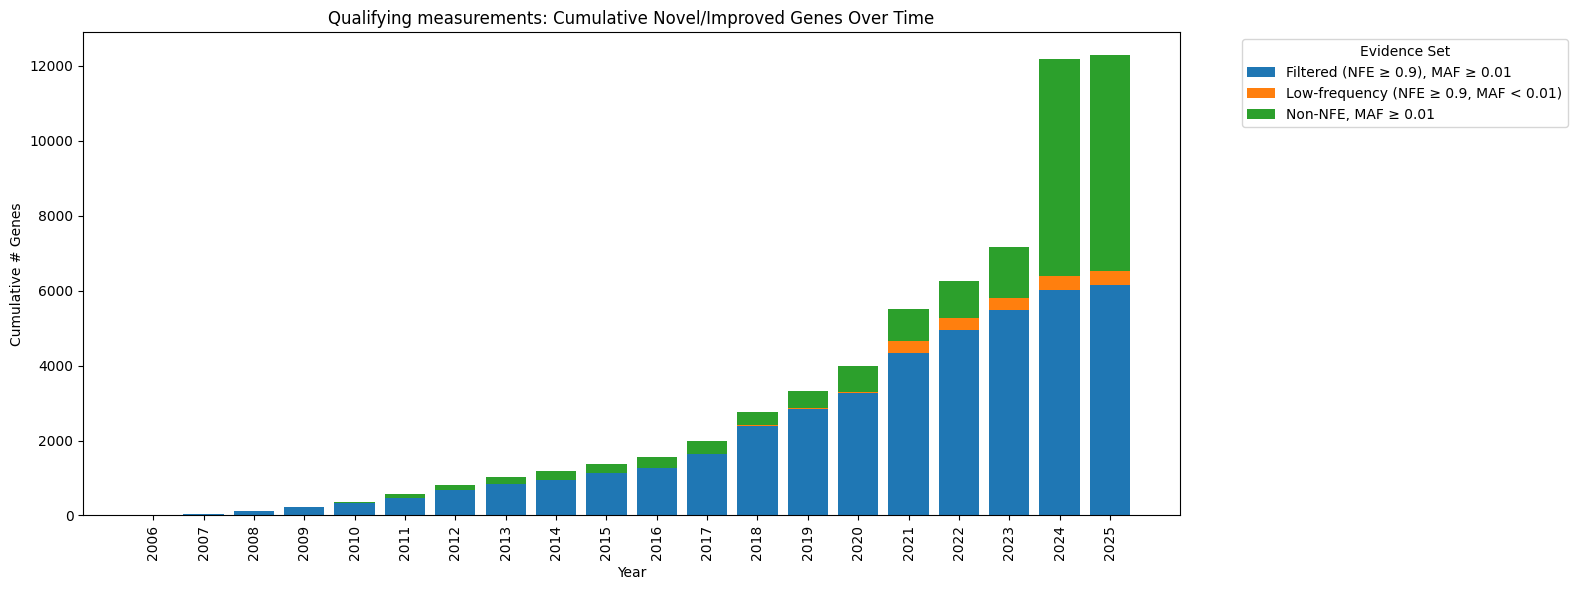

25/08/04 10:37:18 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/08/04 10:37:18 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/08/04 10:37:18 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/08/04 10:37:18 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/08/04 10:37:18 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/08/04 10:37:18 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/08/04 1

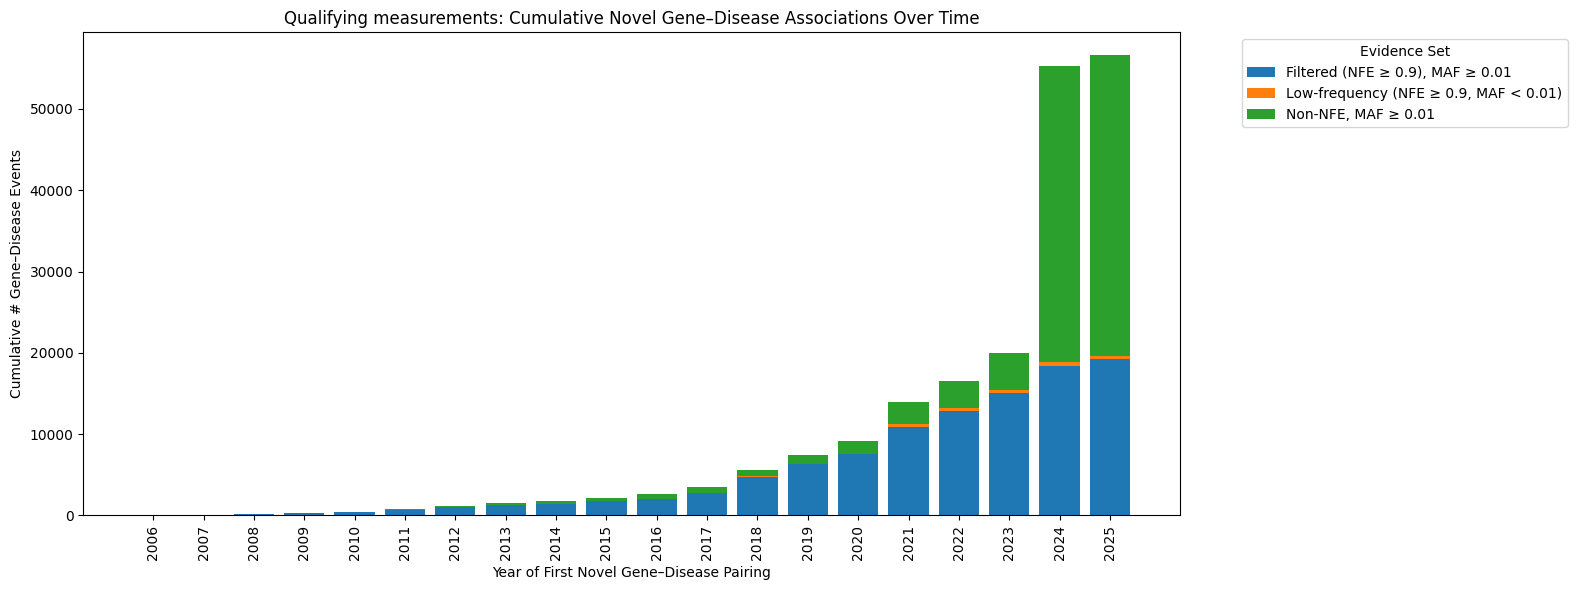

25/08/04 10:38:05 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/08/04 10:38:05 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/08/04 10:38:05 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/08/04 10:38:05 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/08/04 10:38:05 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/08/04 10:38:05 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/08/04 1

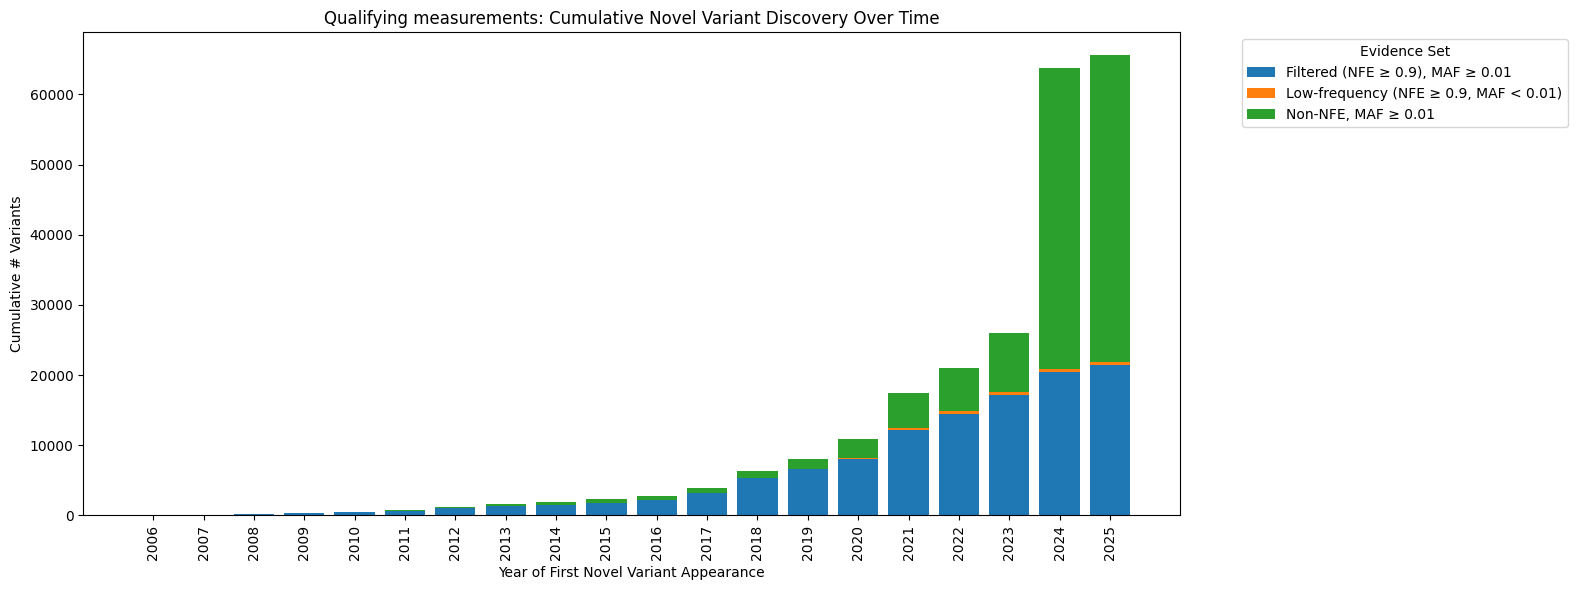

In [3]:
import pyspark.sql.functions as F
from pyspark.sql import Window
import matplotlib.pyplot as plt
from gentropy.dataset.study_locus import StudyLocus

# ——————————————————————————————————————————————————————————————————
# Helpers
# ——————————————————————————————————————————————————————————————————


def load_study_index(path):
    si = session.spark.read.parquet(path)
    si = si.withColumn(
        "publicationDate",
        F.when(F.col("projectId") == "FINNGEN_R12", F.lit("2024-11-04")).otherwise(F.col("publicationDate")),
    )
    si = si.withColumn("publicationDate", F.to_date("publicationDate", "yyyy-MM-dd"))
    si = si.withColumn("publicationYear", F.year("publicationDate"))
    return si.filter(F.col("publicationYear").isNotNull())


def make_nfe_index(si):
    # keep diseaseIds so downstream gene–disease plot works
    return si.filter(
        F.size(
            F.expr("""
                filter(ldPopulationStructure,
                       x -> x.ldPopulation = 'nfe'
                            AND x.relativeSampleSize >= 0.9)
            """)
        )
        > 0
    ).select("studyId", "diseaseIds", "publicationYear")


def compute_events(df, key_cols):
    df2 = df.withColumn(
        "evidence_rank",
        F.when(F.col("score") >= 0.75, 5)
        .when(F.col("score") >= 0.50, 4)
        .when(F.col("score") >= 0.25, 3)
        .when(F.col("score") >= 0.10, 2)
        .otherwise(1),
    )
    for c in key_cols + ["publicationYear"]:
        df2 = df2.filter(F.col(c).isNotNull())

    grp = key_cols + ["publicationYear"]
    pairing = df2.groupBy(*grp).agg(F.max("evidence_rank").alias("max_rank"))

    w = Window.partitionBy(*key_cols).orderBy("publicationYear").rowsBetween(Window.unboundedPreceding, -1)
    pairing = pairing.withColumn("prev_max_rank", F.max("max_rank").over(w)).withColumn(
        "is_event",
        F.when(F.col("prev_max_rank").isNull() | (F.col("max_rank") > F.col("prev_max_rank")), True).otherwise(False),
    )
    return pairing.filter("is_event")


def cumulative_first(events_df, key_cols, count_name):
    first = events_df.groupBy(*key_cols).agg(F.min("publicationYear").alias("first_year"))
    per = first.groupBy("first_year").count().withColumnRenamed("count", count_name)
    w = Window.orderBy("first_year").rowsBetween(Window.unboundedPreceding, 0)
    return per.withColumn(f"cumulative_{count_name}", F.sum(count_name).over(w))


def plot_stacked(merged, year_col, segments, xlabel, ylabel, title):
    # categorical x-axis
    x = merged[year_col].astype(str).tolist()

    plt.figure(figsize=(12, 6))
    bottom = None
    for label, col in segments:
        vals = merged[col]
        plt.bar(x, vals, bottom=bottom, label=label)
        bottom = vals if bottom is None else bottom + vals

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.legend(title="Evidence Set", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.show()


def plot_genes(si, si_nfe, l2g_df, l2g_preds, cred_df):
    base = l2g_df.join(l2g_preds, ["studyLocusId", "geneId"]).join(
        cred_df.select("studyLocusId", "studyId", "effectAlleleFrequencyFromSource"), "studyLocusId"
    )
    gene_f = base.join(si_nfe, "studyId")
    gene_u = base.join(si.select("studyId", "publicationYear"), "studyId")
    gene_l = gene_f.filter(F.col("effectAlleleFrequencyFromSource") < 0.01)

    ev_f = compute_events(gene_f, ["geneId"])
    ev_u = compute_events(gene_u, ["geneId"])
    ev_l = compute_events(gene_l, ["geneId"])

    cum_f = cumulative_first(ev_f, ["geneId"], "new_gene_f")
    cum_u = cumulative_first(ev_u, ["geneId"], "new_gene_u")
    cum_l = cumulative_first(ev_l, ["geneId"], "new_gene_l")

    merged = (
        cum_f.select("first_year", "cumulative_new_gene_f")
        .join(cum_u.select("first_year", "cumulative_new_gene_u"), "first_year", "outer")
        .join(cum_l.select("first_year", "cumulative_new_gene_l"), "first_year", "outer")
        .fillna(0)
        .toPandas()
        .sort_values("first_year")
    )
    merged["gap"] = merged["cumulative_new_gene_u"] - merged["cumulative_new_gene_f"]

    plot_stacked(
        merged,
        "first_year",
        [
            ("Filtered (NFE ≥ 0.9), MAF ≥ 0.01", "cumulative_new_gene_f"),
            ("Low-frequency (NFE ≥ 0.9, MAF < 0.01)", "cumulative_new_gene_l"),
            ("Non-NFE, MAF ≥ 0.01", "gap"),
        ],
        xlabel="Year",
        ylabel="Cumulative # Genes",
        title="Qualifying measurements: Cumulative Novel/Improved Genes Over Time",
    )


def plot_gene_disease(si, si_nfe, l2g_df, l2g_preds, cred_df):
    base = l2g_df.join(l2g_preds, ["studyLocusId", "geneId"]).join(
        cred_df.select("studyLocusId", "studyId", "effectAlleleFrequencyFromSource"), "studyLocusId"
    )
    gd_f = base.join(si_nfe, "studyId")
    gd_u = base.join(si.select("studyId", "diseaseIds", "publicationYear"), "studyId")
    gd_l = gd_f.filter(F.col("effectAlleleFrequencyFromSource") < 0.01)

    ev_f = compute_events(gd_f, ["geneId", "diseaseIds"])
    ev_u = compute_events(gd_u, ["geneId", "diseaseIds"])
    ev_l = compute_events(gd_l, ["geneId", "diseaseIds"])

    cum_f = cumulative_first(ev_f, ["geneId", "diseaseIds"], "new_pair_f")
    cum_u = cumulative_first(ev_u, ["geneId", "diseaseIds"], "new_pair_u")
    cum_l = cumulative_first(ev_l, ["geneId", "diseaseIds"], "new_pair_l")

    merged = (
        cum_f.select("first_year", "cumulative_new_pair_f")
        .join(cum_u.select("first_year", "cumulative_new_pair_u"), "first_year", "outer")
        .join(cum_l.select("first_year", "cumulative_new_pair_l"), "first_year", "outer")
        .fillna(0)
        .toPandas()
        .sort_values("first_year")
    )
    merged["gap"] = merged["cumulative_new_pair_u"] - merged["cumulative_new_pair_f"]

    plot_stacked(
        merged,
        "first_year",
        [
            ("Filtered (NFE ≥ 0.9), MAF ≥ 0.01", "cumulative_new_pair_f"),
            ("Low-frequency (NFE ≥ 0.9, MAF < 0.01)", "cumulative_new_pair_l"),
            ("Non-NFE, MAF ≥ 0.01", "gap"),
        ],
        xlabel="Year of First Novel Gene–Disease Pairing",
        ylabel="Cumulative # Gene–Disease Events",
        title="Qualifying measurements: Cumulative Novel Gene–Disease Associations Over Time",
    )


def plot_variants(si, si_nfe, cred_df):
    nov = (
        cred_df.select("studyLocusId", "studyId", "variantId", "effectAlleleFrequencyFromSource")
        .join(si.select("studyId", "publicationYear", "ldPopulationStructure"), "studyId")
        .filter(F.col("variantId").isNotNull())
    )
    v_f = nov.filter(
        F.size(
            F.expr("""
                filter(ldPopulationStructure,
                       x -> x.ldPopulation = 'nfe'
                            AND x.relativeSampleSize >= 0.9)
            """)
        )
        > 0
    )
    v_u = nov
    v_l = v_f.filter(F.col("effectAlleleFrequencyFromSource") < 0.01)

    def cum_var(df, name):
        first = df.groupBy("variantId").agg(F.min("publicationYear").alias("first_year"))
        per = first.groupBy("first_year").count().withColumnRenamed("count", name)
        w = Window.orderBy("first_year").rowsBetween(Window.unboundedPreceding, 0)
        return per.withColumn(f"cumulative_{name}", F.sum(name).over(w))

    cum_f = cum_var(v_f, "new_var_f")
    cum_u = cum_var(v_u, "new_var_u")
    cum_l = cum_var(v_l, "new_var_l")

    merged = (
        cum_f.select("first_year", "cumulative_new_var_f")
        .join(cum_u.select("first_year", "cumulative_new_var_u"), "first_year", "outer")
        .join(cum_l.select("first_year", "cumulative_new_var_l"), "first_year", "outer")
        .fillna(0)
        .toPandas()
        .sort_values("first_year")
    )
    merged["gap"] = merged["cumulative_new_var_u"] - merged["cumulative_new_var_f"]

    plot_stacked(
        merged,
        "first_year",
        [
            ("Filtered (NFE ≥ 0.9), MAF ≥ 0.01", "cumulative_new_var_f"),
            ("Low-frequency (NFE ≥ 0.9, MAF < 0.01)", "cumulative_new_var_l"),
            ("Non-NFE, MAF ≥ 0.01", "gap"),
        ],
        xlabel="Year of First Novel Variant Appearance",
        ylabel="Cumulative # Variants",
        title="Qualifying measurements: Cumulative Novel Variant Discovery Over Time",
    )


def run_all(study_index_path):
    si = load_study_index(study_index_path)
    si_nfe = make_nfe_index(si)

    l2g_df = session.spark.read.parquet(
        "gs://genetics-portal-dev-analysis/yt4/20250403_for_gentropy_paper/list_of_prioritised_genes_per_CS.parquet"
    ).drop("score")
    l2g_preds = session.spark.read.parquet("gs://ot-team/irene/l2g/xgboost/2706/l2g_predictions")
    cred = StudyLocus.from_parquet(session, "gs://open-targets-data-releases/25.06/output/credible_set")
    cred_df = cred.df

    plot_genes(si, si_nfe, l2g_df, l2g_preds, cred_df)
    plot_gene_disease(si, si_nfe, l2g_df, l2g_preds, cred_df)
    plot_variants(si, si_nfe, cred_df)


# run :
run_all("gs://genetics-portal-dev-analysis/dc16/output/gentropy_paper/qualifying_studies")

25/08/04 10:39:09 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/08/04 10:39:09 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/08/04 10:39:09 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/08/04 10:39:09 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/08/04 10:39:09 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/08/04 10:39:09 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/08/04 1

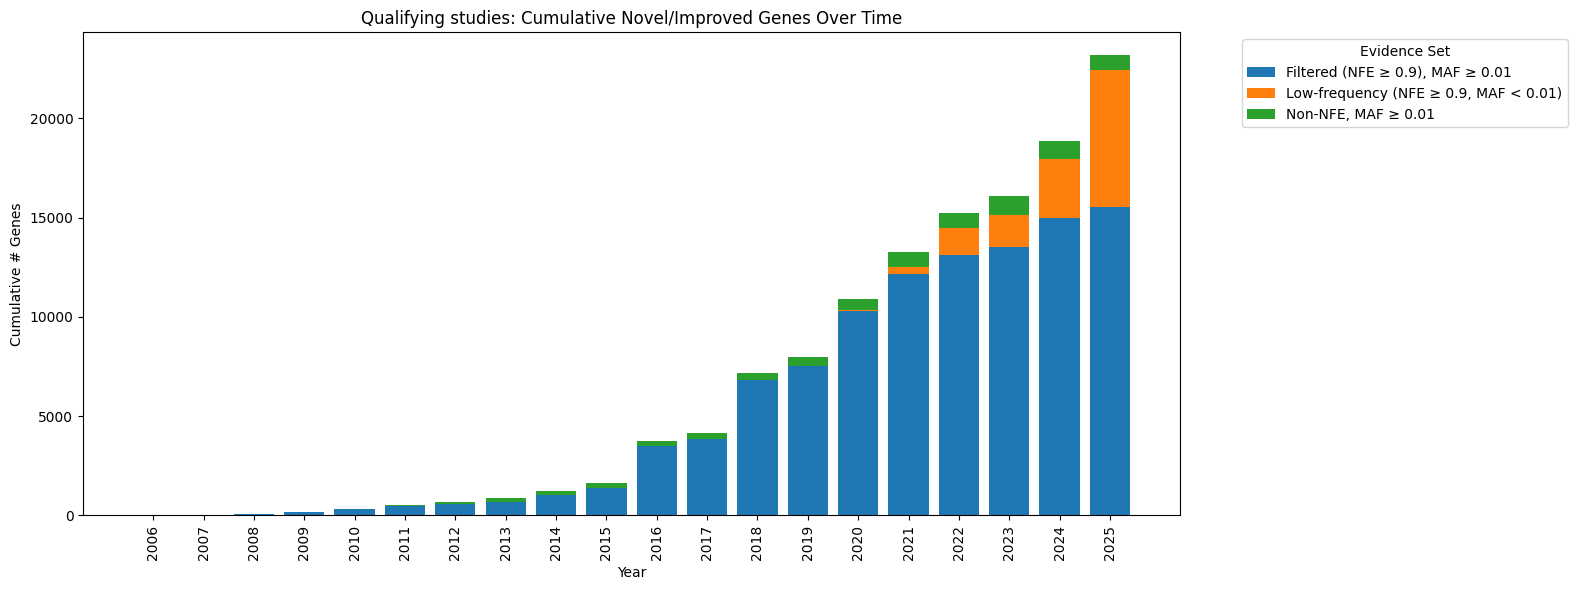

25/08/04 10:39:53 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/08/04 10:39:53 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/08/04 10:39:53 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/08/04 10:39:53 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/08/04 10:39:53 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/08/04 10:39:53 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/08/04 1

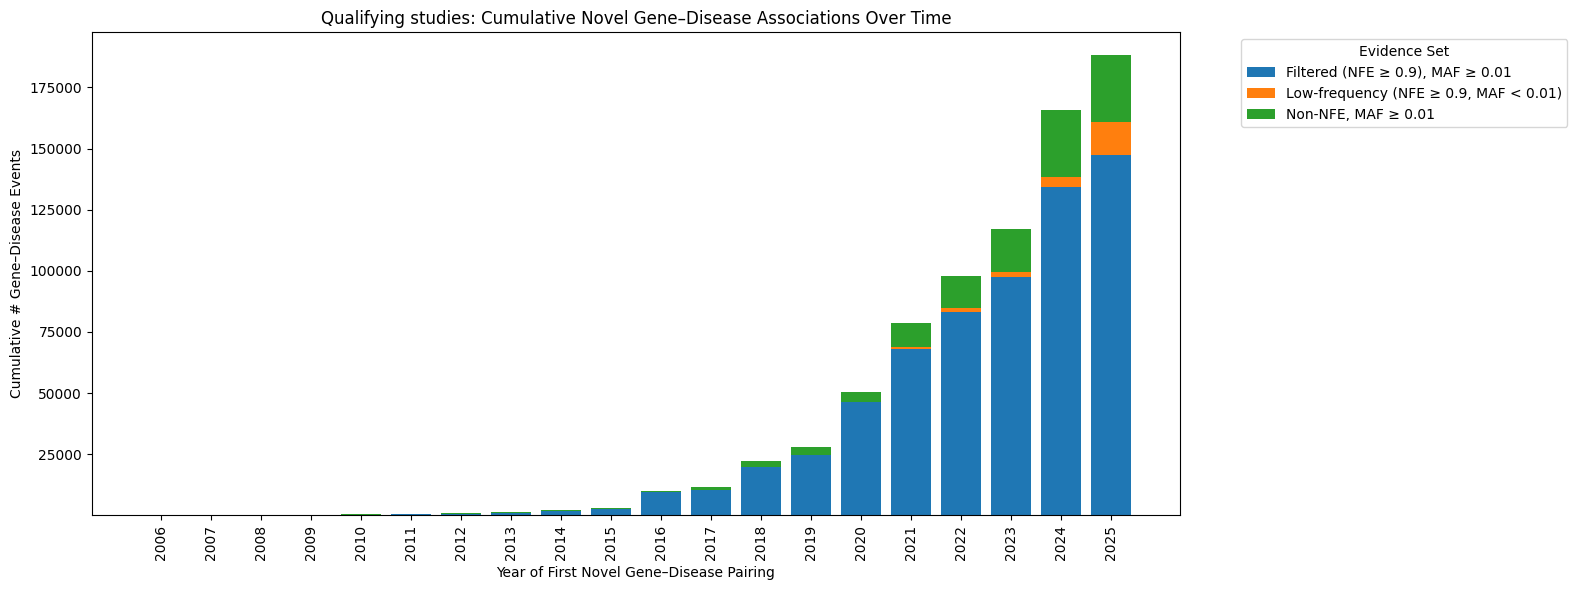

25/08/04 10:41:11 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/08/04 10:41:11 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/08/04 10:41:11 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/08/04 10:41:11 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/08/04 10:41:11 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/08/04 10:41:11 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/08/04 1

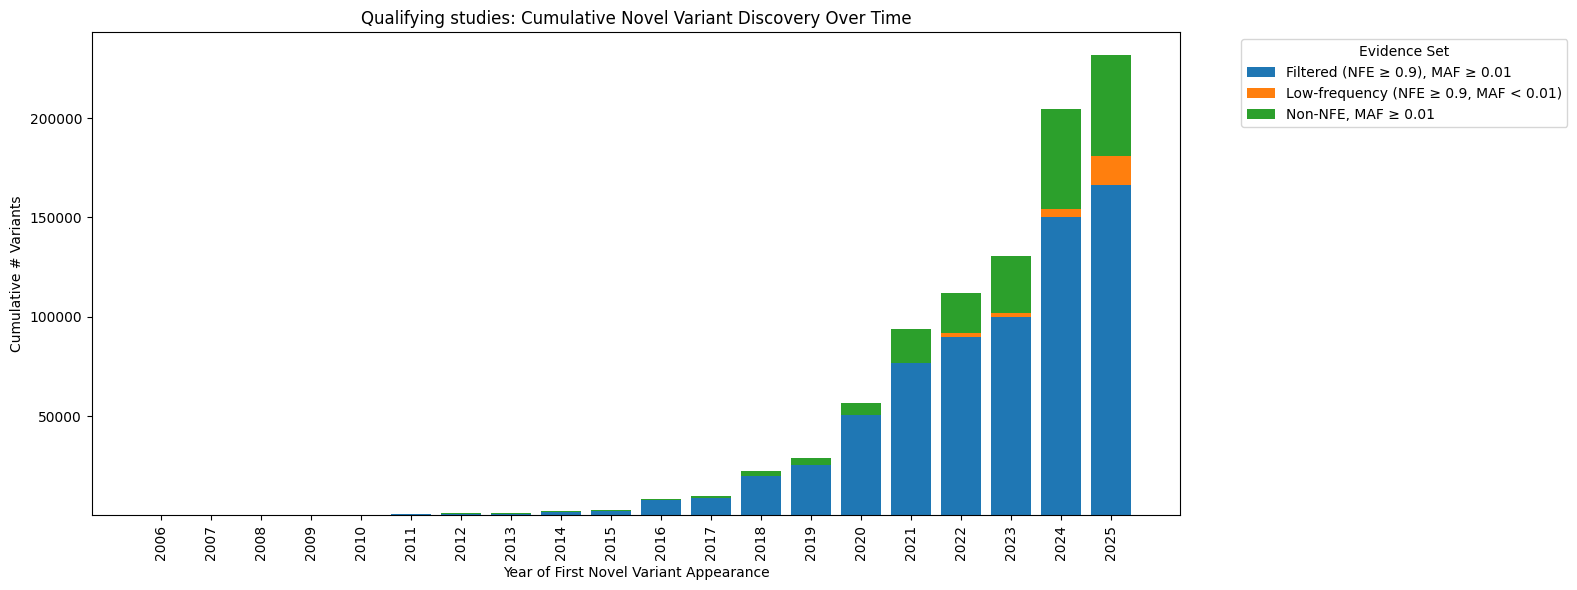

In [4]:
import pyspark.sql.functions as F
from pyspark.sql import Window
import matplotlib.pyplot as plt
from gentropy.dataset.study_locus import StudyLocus


def load_study_index(path):
    si = session.spark.read.parquet(path)
    si = si.withColumn(
        "publicationDate",
        F.when(F.col("projectId") == "FINNGEN_R12", F.lit("2024-11-04")).otherwise(F.col("publicationDate")),
    )
    si = si.withColumn("publicationDate", F.to_date("publicationDate", "yyyy-MM-dd"))
    si = si.withColumn("publicationYear", F.year("publicationDate"))
    return si.filter(F.col("publicationYear").isNotNull())


def make_nfe_index(si):
    return si.filter(
        F.size(
            F.expr("""
                filter(ldPopulationStructure,
                       x -> x.ldPopulation = 'nfe'
                            AND x.relativeSampleSize >= 0.9)
            """)
        )
        > 0
    ).select("studyId", "diseaseIds", "publicationYear")


def compute_events(df, key_cols):
    df2 = df.withColumn(
        "evidence_rank",
        F.when(F.col("score") >= 0.75, 5)
        .when(F.col("score") >= 0.50, 4)
        .when(F.col("score") >= 0.25, 3)
        .when(F.col("score") >= 0.10, 2)
        .otherwise(1),
    )
    for c in key_cols + ["publicationYear"]:
        df2 = df2.filter(F.col(c).isNotNull())

    grp = key_cols + ["publicationYear"]
    pairing = df2.groupBy(*grp).agg(F.max("evidence_rank").alias("max_rank"))

    w = Window.partitionBy(*key_cols).orderBy("publicationYear").rowsBetween(Window.unboundedPreceding, -1)
    pairing = pairing.withColumn("prev_max_rank", F.max("max_rank").over(w)).withColumn(
        "is_event",
        F.when(F.col("prev_max_rank").isNull() | (F.col("max_rank") > F.col("prev_max_rank")), True).otherwise(False),
    )
    return pairing.filter("is_event")


def cumulative_first(events_df, key_cols, count_name):
    first = events_df.groupBy(*key_cols).agg(F.min("publicationYear").alias("first_year"))
    per = first.groupBy("first_year").count().withColumnRenamed("count", count_name)
    w = Window.orderBy("first_year").rowsBetween(Window.unboundedPreceding, 0)
    return per.withColumn(f"cumulative_{count_name}", F.sum(count_name).over(w))


def plot_stacked(merged, year_col, segments, xlabel, ylabel, title):
    x = merged[year_col].astype(str).tolist()

    plt.figure(figsize=(12, 6))
    bottom = None
    for label, col in segments:
        vals = merged[col]
        plt.bar(x, vals, bottom=bottom, label=label)
        bottom = vals if bottom is None else bottom + vals

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.legend(title="Evidence Set", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.show()


def plot_genes(si, si_nfe, l2g_df, l2g_preds, cred_df):
    base = l2g_df.join(l2g_preds, ["studyLocusId", "geneId"]).join(
        cred_df.select("studyLocusId", "studyId", "effectAlleleFrequencyFromSource"), "studyLocusId"
    )
    gene_f = base.join(si_nfe, "studyId")
    gene_u = base.join(si.select("studyId", "publicationYear"), "studyId")
    gene_l = gene_f.filter(F.col("effectAlleleFrequencyFromSource") < 0.01)

    ev_f = compute_events(gene_f, ["geneId"])
    ev_u = compute_events(gene_u, ["geneId"])
    ev_l = compute_events(gene_l, ["geneId"])

    cum_f = cumulative_first(ev_f, ["geneId"], "new_gene_f")
    cum_u = cumulative_first(ev_u, ["geneId"], "new_gene_u")
    cum_l = cumulative_first(ev_l, ["geneId"], "new_gene_l")

    merged = (
        cum_f.select("first_year", "cumulative_new_gene_f")
        .join(cum_u.select("first_year", "cumulative_new_gene_u"), "first_year", "outer")
        .join(cum_l.select("first_year", "cumulative_new_gene_l"), "first_year", "outer")
        .fillna(0)
        .toPandas()
        .sort_values("first_year")
    )
    merged["gap"] = merged["cumulative_new_gene_u"] - merged["cumulative_new_gene_f"]

    plot_stacked(
        merged,
        "first_year",
        [
            ("Filtered (NFE ≥ 0.9), MAF ≥ 0.01", "cumulative_new_gene_f"),
            ("Low-frequency (NFE ≥ 0.9, MAF < 0.01)", "cumulative_new_gene_l"),
            ("Non-NFE, MAF ≥ 0.01", "gap"),
        ],
        xlabel="Year",
        ylabel="Cumulative # Genes",
        title="Qualifying studies: Cumulative Novel/Improved Genes Over Time",
    )


def plot_gene_disease(si, si_nfe, l2g_df, l2g_preds, cred_df):
    base = l2g_df.join(l2g_preds, ["studyLocusId", "geneId"]).join(
        cred_df.select("studyLocusId", "studyId", "effectAlleleFrequencyFromSource"), "studyLocusId"
    )
    gd_f = base.join(si_nfe, "studyId")
    gd_u = base.join(si.select("studyId", "diseaseIds", "publicationYear"), "studyId")
    gd_l = gd_f.filter(F.col("effectAlleleFrequencyFromSource") < 0.01)

    ev_f = compute_events(gd_f, ["geneId", "diseaseIds"])
    ev_u = compute_events(gd_u, ["geneId", "diseaseIds"])
    ev_l = compute_events(gd_l, ["geneId", "diseaseIds"])

    cum_f = cumulative_first(ev_f, ["geneId", "diseaseIds"], "new_pair_f")
    cum_u = cumulative_first(ev_u, ["geneId", "diseaseIds"], "new_pair_u")
    cum_l = cumulative_first(ev_l, ["geneId", "diseaseIds"], "new_pair_l")

    merged = (
        cum_f.select("first_year", "cumulative_new_pair_f")
        .join(cum_u.select("first_year", "cumulative_new_pair_u"), "first_year", "outer")
        .join(cum_l.select("first_year", "cumulative_new_pair_l"), "first_year", "outer")
        .fillna(0)
        .toPandas()
        .sort_values("first_year")
    )
    merged["gap"] = merged["cumulative_new_pair_u"] - merged["cumulative_new_pair_f"]

    plot_stacked(
        merged,
        "first_year",
        [
            ("Filtered (NFE ≥ 0.9), MAF ≥ 0.01", "cumulative_new_pair_f"),
            ("Low-frequency (NFE ≥ 0.9, MAF < 0.01)", "cumulative_new_pair_l"),
            ("Non-NFE, MAF ≥ 0.01", "gap"),
        ],
        xlabel="Year of First Novel Gene–Disease Pairing",
        ylabel="Cumulative # Gene–Disease Events",
        title="Qualifying studies: Cumulative Novel Gene–Disease Associations Over Time",
    )


def plot_variants(si, si_nfe, cred_df):
    nov = (
        cred_df.select("studyLocusId", "studyId", "variantId", "effectAlleleFrequencyFromSource")
        .join(si.select("studyId", "publicationYear", "ldPopulationStructure"), "studyId")
        .filter(F.col("variantId").isNotNull())
    )
    v_f = nov.filter(
        F.size(
            F.expr("""
                filter(ldPopulationStructure,
                       x -> x.ldPopulation = 'nfe'
                            AND x.relativeSampleSize >= 0.9)
            """)
        )
        > 0
    )
    v_u = nov
    v_l = v_f.filter(F.col("effectAlleleFrequencyFromSource") < 0.01)

    def cum_var(df, name):
        first = df.groupBy("variantId").agg(F.min("publicationYear").alias("first_year"))
        per = first.groupBy("first_year").count().withColumnRenamed("count", name)
        w = Window.orderBy("first_year").rowsBetween(Window.unboundedPreceding, 0)
        return per.withColumn(f"cumulative_{name}", F.sum(name).over(w))

    cum_f = cum_var(v_f, "new_var_f")
    cum_u = cum_var(v_u, "new_var_u")
    cum_l = cum_var(v_l, "new_var_l")

    merged = (
        cum_f.select("first_year", "cumulative_new_var_f")
        .join(cum_u.select("first_year", "cumulative_new_var_u"), "first_year", "outer")
        .join(cum_l.select("first_year", "cumulative_new_var_l"), "first_year", "outer")
        .fillna(0)
        .toPandas()
        .sort_values("first_year")
    )
    merged["gap"] = merged["cumulative_new_var_u"] - merged["cumulative_new_var_f"]

    plot_stacked(
        merged,
        "first_year",
        [
            ("Filtered (NFE ≥ 0.9), MAF ≥ 0.01", "cumulative_new_var_f"),
            ("Low-frequency (NFE ≥ 0.9, MAF < 0.01)", "cumulative_new_var_l"),
            ("Non-NFE, MAF ≥ 0.01", "gap"),
        ],
        xlabel="Year of First Novel Variant Appearance",
        ylabel="Cumulative # Variants",
        title="Qualifying studies: Cumulative Novel Variant Discovery Over Time",
    )


def run_all(study_index_path):
    si = load_study_index(study_index_path)
    si_nfe = make_nfe_index(si)

    l2g_df = session.spark.read.parquet(
        "gs://genetics-portal-dev-analysis/yt4/20250403_for_gentropy_paper/list_of_prioritised_genes_per_CS.parquet"
    ).drop("score")
    l2g_preds = session.spark.read.parquet("gs://ot-team/irene/l2g/xgboost/2706/l2g_predictions")
    cred = StudyLocus.from_parquet(session, "gs://open-targets-data-releases/25.06/output/credible_set")
    cred_df = cred.df

    plot_genes(si, si_nfe, l2g_df, l2g_preds, cred_df)
    plot_gene_disease(si, si_nfe, l2g_df, l2g_preds, cred_df)
    plot_variants(si, si_nfe, cred_df)


# run index:
run_all("gs://genetics-portal-dev-analysis/dc16/output/gentropy_paper/qualifying_measurements")

25/08/04 10:48:10 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/08/04 10:48:10 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/08/04 10:48:10 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/08/04 10:48:10 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/08/04 10:48:10 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/08/04 10:48:10 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/08/04 1

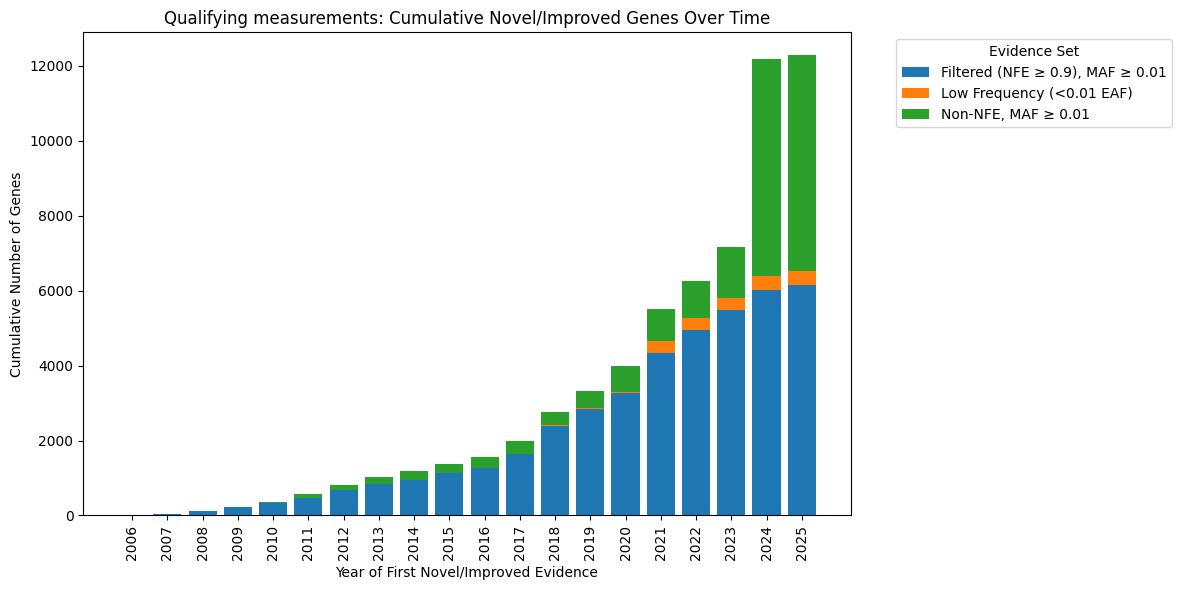

25/08/04 10:49:42 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/08/04 10:49:42 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/08/04 10:49:42 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/08/04 10:49:42 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/08/04 10:49:42 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/08/04 10:49:42 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/08/04 1

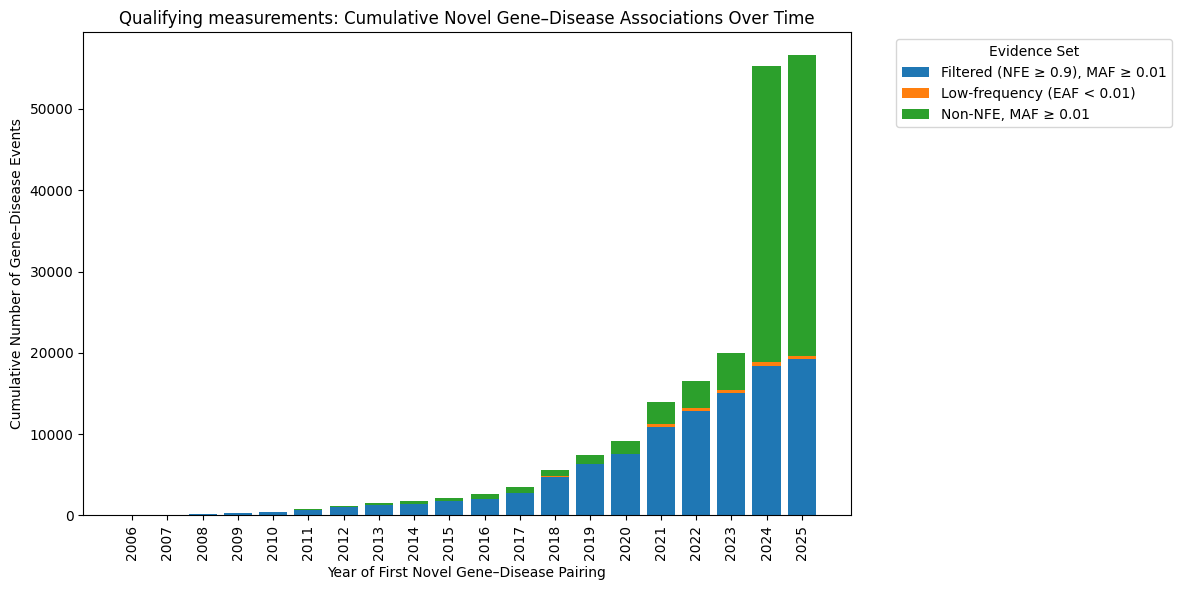

25/08/04 10:51:03 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/08/04 10:51:03 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/08/04 10:51:03 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/08/04 10:51:03 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/08/04 10:51:03 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/08/04 10:51:03 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/08/04 1

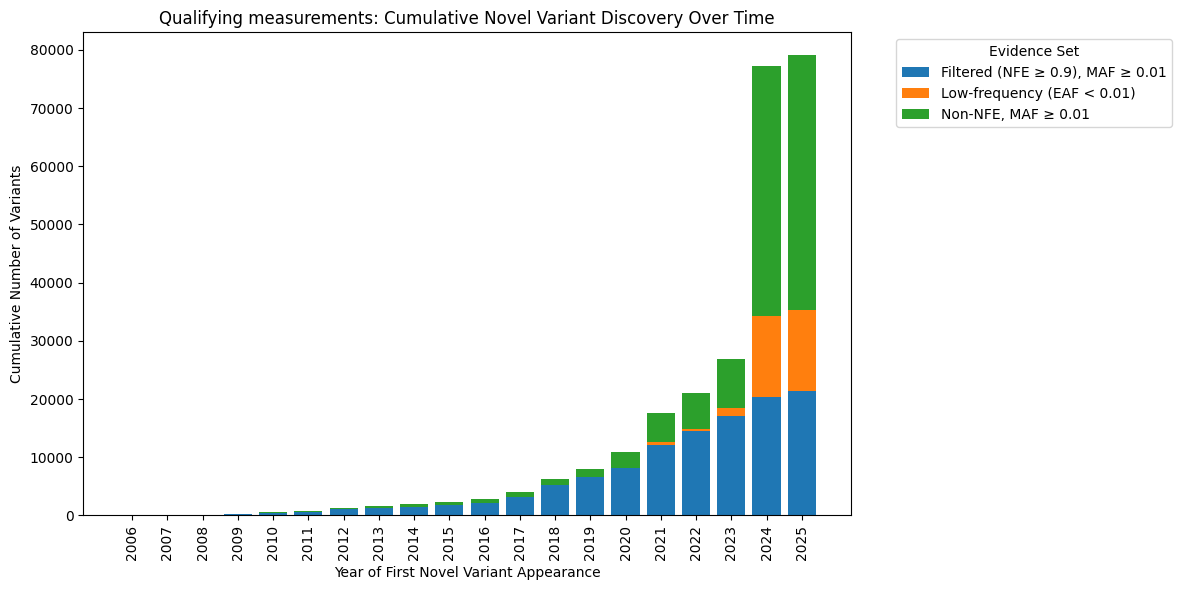

In [7]:
# Load necessary datasets
study_index_df = session.spark.read.parquet(
    "gs://genetics-portal-dev-analysis/dc16/output/gentropy_paper/qualifying_studies"
)
l2g_prioritised_genes_df = session.spark.read.parquet(
    "gs://genetics-portal-dev-analysis/yt4/20250403_for_gentropy_paper/list_of_prioritised_genes_per_CS.parquet"
).drop("score")
locus_to_gene_prediction = session.spark.read.parquet("gs://ot-team/irene/l2g/xgboost/2706/l2g_predictions")
from gentropy.dataset.study_locus import StudyLocus

credible_set = StudyLocus.from_parquet(session, "gs://open-targets-data-releases/25.06/output/credible_set")

import pyspark.sql.functions as f
from pyspark.sql import Window

study_index_df = study_index_df.withColumn(
    "publicationDate",
    f.when(f.col("projectId") == "FINNGEN_R12", f.lit("2024-11-04")).otherwise(f.col("publicationDate")),
)
study_index_df = study_index_df.withColumn("publicationDate", f.to_date(f.col("publicationDate"), "yyyy-MM-dd"))
study_index_df = study_index_df.withColumn("publicationYear", f.year("publicationDate"))
study_index_df = study_index_df.filter(f.col("publicationYear").isNotNull())

study_index_df_nfe = study_index_df.filter(
    f.size(
        f.filter(
            f.col("ldPopulationStructure"), lambda x: (x["ldPopulation"] == "nfe") & (x["relativeSampleSize"] >= 0.9)
        )
    )
    > 0
)

locus_to_gene_prediction_df = (
    l2g_prioritised_genes_df.join(locus_to_gene_prediction, ["studyLocusId", "geneId"])
    .join(
        credible_set.df.select("studyLocusId", "studyId", "variantId", "effectAlleleFrequencyFromSource"),
        "studyLocusId",
    )
    .join(study_index_df_nfe.select("studyId", "publicationYear"), "studyId")
)

locus_to_gene_prediction_df_unfiltered = (
    l2g_prioritised_genes_df.join(locus_to_gene_prediction, ["studyLocusId", "geneId"])
    .join(
        credible_set.df.select("studyLocusId", "studyId", "variantId", "effectAlleleFrequencyFromSource"),
        "studyLocusId",
    )
    .join(study_index_df.select("studyId", "publicationYear"), "studyId")
)


def compute_events(df):
    df = df.withColumn(
        "evidence_rank",
        f.when(f.col("score") >= 0.75, 5)
        .when(f.col("score") >= 0.5, 4)
        .when(f.col("score") >= 0.25, 3)
        .when(f.col("score") >= 0.1, 2)
        .otherwise(1),
    ).filter(f.col("geneId").isNotNull() & f.col("publicationYear").isNotNull())

    gene_year = df.groupBy("geneId", "publicationYear").agg(f.max("evidence_rank").alias("max_rank"))

    w = Window.partitionBy("geneId").orderBy("publicationYear").rowsBetween(Window.unboundedPreceding, -1)
    gene_year = gene_year.withColumn("prev_max_rank", f.max("max_rank").over(w))
    gene_year = gene_year.withColumn(
        "is_event",
        f.when((f.col("prev_max_rank").isNull()) | (f.col("max_rank") > f.col("prev_max_rank")), True).otherwise(False),
    )

    return gene_year.filter(f.col("is_event") == True)


events_filtered = compute_events(locus_to_gene_prediction_df)
events_unfiltered = compute_events(locus_to_gene_prediction_df_unfiltered)

# Filter to low-frequency
lowfreq_df = locus_to_gene_prediction_df.filter(f.col("effectAlleleFrequencyFromSource") < 0.01)
events_lowfreq = compute_events(lowfreq_df)


def cumulative_df(events_df, col_name):
    first_event = events_df.groupBy("geneId").agg(f.min("publicationYear").alias("first_year"))
    per_year = first_event.groupBy("first_year").count().withColumnRenamed("count", col_name)
    w = Window.orderBy("first_year").rowsBetween(Window.unboundedPreceding, 0)
    return per_year.withColumn(f"cumulative_{col_name}", f.sum(col_name).over(w))


cum_filtered = cumulative_df(events_filtered, "new_gene_filtered")
cum_unfiltered = cumulative_df(events_unfiltered, "new_gene_unfiltered")
cum_lowfreq = cumulative_df(events_lowfreq, "new_gene_lowfreq")

merged_cum = (
    cum_filtered.select("first_year", "cumulative_new_gene_filtered")
    .join(cum_unfiltered.select("first_year", "cumulative_new_gene_unfiltered"), "first_year", "outer")
    .join(cum_lowfreq.select("first_year", "cumulative_new_gene_lowfreq"), "first_year", "outer")
    .fillna(0)
    .toPandas()
)

merged_cum = merged_cum.sort_values("first_year")
merged_cum["first_year"] = merged_cum["first_year"].astype(int).astype(str)
merged_cum["gap"] = merged_cum["cumulative_new_gene_unfiltered"] - merged_cum["cumulative_new_gene_filtered"]

import matplotlib.pyplot as plt

# ensure your first_year is string/categorical
merged_cum["first_year"] = merged_cum["first_year"].astype(str)

plt.figure(figsize=(12, 6))

# 1) NFE common (we'll pretend 'filtered' is common MAF>=0.01)
plt.bar(merged_cum["first_year"], merged_cum["cumulative_new_gene_filtered"], label="Filtered (NFE ≥ 0.9), MAF ≥ 0.01")

# 2) NFE rare
plt.bar(
    merged_cum["first_year"],
    merged_cum["cumulative_new_gene_lowfreq"],
    bottom=merged_cum["cumulative_new_gene_filtered"],
    label="Low Frequency (<0.01 EAF)",
)

# 3) non-NFE
plt.bar(
    merged_cum["first_year"],
    merged_cum["gap"],
    bottom=merged_cum["cumulative_new_gene_filtered"] + merged_cum["cumulative_new_gene_lowfreq"],
    label="Non-NFE, MAF ≥ 0.01",
)

plt.xlabel("Year of First Novel/Improved Evidence")
plt.ylabel("Cumulative Number of Genes")
plt.title("Qualifying measurements: Cumulative Novel/Improved Genes Over Time")
plt.xticks(rotation=90)
plt.legend(title="Evidence Set", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# ——————————————————————————————————————————————————————————————————
# 1) Make sure we carry diseaseId through the study_index joins
# ——————————————————————————————————————————————————————————————————

# after you’ve parsed publicationDate/year:
# (replace `diseaseId` below by whatever your column is called in qualifying_studies)
study_index_df = study_index_df.withColumn("diseaseIds", f.col("diseaseIds")).select(
    "studyId", "diseaseIds", "publicationDate", "publicationYear", "ldPopulationStructure"
)

study_index_df_nfe = study_index_df.filter(
    f.size(
        f.filter(
            f.col("ldPopulationStructure"), lambda x: (x["ldPopulation"] == "nfe") & (x["relativeSampleSize"] >= 0.9)
        )
    )
    > 0
).select("studyId", "diseaseIds", "publicationYear")

# ——————————————————————————————————————————————————————————————————
# 2) Join diseaseId into your three DataFrames
# ——————————————————————————————————————————————————————————————————

base = l2g_prioritised_genes_df.join(locus_to_gene_prediction, ["studyLocusId", "geneId"]).join(
    credible_set.df.select(  # brings in studyId, variantId, EAF
        "studyLocusId", "studyId", "effectAlleleFrequencyFromSource"
    ),
    "studyLocusId",
)

# filtered = NFE-heavy only
l2g_filtered = base.join(study_index_df_nfe, on="studyId", how="inner")

# unfiltered = all studies
l2g_unfiltered = base.join(study_index_df.select("studyId", "diseaseIds", "publicationYear"), on="studyId", how="inner")

# low-frequency (<1% EAF) within NFE studies
l2g_lowfreq = l2g_filtered.filter(f.col("effectAlleleFrequencyFromSource") < 0.01)

# ——————————————————————————————————————————————————————————————————
# 3) compute_events now over (geneId, diseaseId)
# ——————————————————————————————————————————————————————————————————


def compute_events(df):
    df = df.withColumn(
        "evidence_rank",
        f.when(f.col("score") >= 0.75, 5)
        .when(f.col("score") >= 0.50, 4)
        .when(f.col("score") >= 0.25, 3)
        .when(f.col("score") >= 0.10, 2)
        .otherwise(1),
    ).filter(f.col("geneId").isNotNull() & f.col("diseaseIds").isNotNull() & f.col("publicationYear").isNotNull())

    # max rank per gene‐disease per year
    pairing_year = df.groupBy("geneId", "diseaseIds", "publicationYear").agg(f.max("evidence_rank").alias("max_rank"))

    # compare to previous years for that same (gene,disease)
    w = Window.partitionBy("geneId", "diseaseIds").orderBy("publicationYear").rowsBetween(Window.unboundedPreceding, -1)

    pairing_year = pairing_year.withColumn("prev_max_rank", f.max("max_rank").over(w)).withColumn(
        "is_event",
        f.when(f.col("prev_max_rank").isNull() | (f.col("max_rank") > f.col("prev_max_rank")), True).otherwise(False),
    )

    return pairing_year.filter("is_event")


events_filtered = compute_events(l2g_filtered)
events_unfiltered = compute_events(l2g_unfiltered)
events_lowfreq = compute_events(l2g_lowfreq)

# ——————————————————————————————————————————————————————————————————
# 4) cumulative count of *first* event per (gene,disease)
# ——————————————————————————————————————————————————————————————————


def cumulative_df(events_df, col_name):
    # first‐ever event year per pairing
    first_event = events_df.groupBy("geneId", "diseaseIds").agg(f.min("publicationYear").alias("first_year"))
    # how many *new* pairings each year
    per_year = first_event.groupBy("first_year").count().withColumnRenamed("count", col_name)
    # running total
    w = Window.orderBy("first_year").rowsBetween(Window.unboundedPreceding, 0)
    return per_year.withColumn(f"cumulative_{col_name}", f.sum(col_name).over(w))


cum_f = cumulative_df(events_filtered, "new_pair_filtered")
cum_u = cumulative_df(events_unfiltered, "new_pair_unfiltered")
cum_l = cumulative_df(events_lowfreq, "new_pair_lowfreq")

# bring into pandas & compute the “gap”
merged = (
    cum_f.select("first_year", "cumulative_new_pair_filtered")
    .join(cum_u.select("first_year", "cumulative_new_pair_unfiltered"), "first_year", "outer")
    .join(cum_l.select("first_year", "cumulative_new_pair_lowfreq"), "first_year", "outer")
    .fillna(0)
    .toPandas()
    .sort_values("first_year")
)
merged["first_year"] = merged["first_year"].astype(int).astype(str)
merged["gap"] = merged["cumulative_new_pair_unfiltered"] - merged["cumulative_new_pair_filtered"]

# ——————————————————————————————————————————————————————————————————
# 5) plot exactly as before, just relabeled
# ——————————————————————————————————————————————————————————————————

import matplotlib.pyplot as plt

import matplotlib.pyplot as plt

# ensure categorical x-axis
merged["first_year"] = merged["first_year"].astype(str)

plt.figure(figsize=(12, 6))

# 1) NFE common (MAF ≥ 0.01)
plt.bar(merged["first_year"], merged["cumulative_new_pair_filtered"], label="Filtered (NFE ≥ 0.9), MAF ≥ 0.01")

# 2) NFE rare (MAF < 0.01)
plt.bar(
    merged["first_year"],
    merged["cumulative_new_pair_lowfreq"],
    bottom=merged["cumulative_new_pair_filtered"],
    label="Low-frequency (EAF < 0.01)",
)

# 3) Non-NFE (MAF ≥ 0.01)
plt.bar(
    merged["first_year"],
    merged["gap"],
    bottom=merged["cumulative_new_pair_filtered"] + merged["cumulative_new_pair_lowfreq"],
    label="Non-NFE, MAF ≥ 0.01",
)

plt.xlabel("Year of First Novel Gene–Disease Pairing")
plt.ylabel("Cumulative Number of Gene–Disease Events")
plt.title("Qualifying measurements: Cumulative Novel Gene–Disease Associations Over Time")
plt.xticks(rotation=90)
plt.legend(title="Evidence Set", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

from pyspark.sql import functions as F
from pyspark.sql import Window

# Use top-level variantId and publication date
novel_variants = (
    credible_set.df.join(study_index_df, on="studyId", how="inner")
    .withColumn("publicationYear", F.year(F.col("publicationDate")))
    .filter(F.col("variantId").isNotNull() & F.col("publicationYear").isNotNull())
)

from pyspark.sql import functions as F, Window
import matplotlib.pyplot as plt

# 1. define your "NFE-heavy" study filter (you already have study_index_df_nfe)
#    and reuse novel_variants (which must include ldPopulationStructure & EAF).
#    If you need to refilter by joining, do:
# novel_variants = credible_set.df \
#    .join(study_index_df, on="studyId", how="inner") \
#    .withColumn("publicationYear", F.year("publicationDate")) \
#    .filter("variantId IS NOT NULL AND publicationYear IS NOT NULL")

# 2. make the three subsets
variants_filtered = novel_variants.filter(
    F.size(
        F.expr("""filter(ldPopulationStructure,
                          x -> x.ldPopulation = 'nfe' AND x.relativeSampleSize >= 0.9)""")
    )
    > 0
)

variants_lowfreq = novel_variants.filter(F.col("effectAlleleFrequencyFromSource") < 0.01)

variants_unfiltered = novel_variants  # all variants


def cumulative_variants(df, count_name):
    # first appearance per variant
    first = df.groupBy("variantId").agg(F.min("publicationYear").alias("first_year"))
    # count new per year
    per_year = first.groupBy("first_year").count().withColumnRenamed("count", count_name)
    # cumulative sum over time
    w = Window.orderBy("first_year").rowsBetween(Window.unboundedPreceding, 0)
    return per_year.withColumn(f"cumulative_{count_name}", F.sum(count_name).over(w))


# 3. build cumulatives
cum_f = cumulative_variants(variants_filtered, "new_var_filtered")
cum_u = cumulative_variants(variants_unfiltered, "new_var_unfiltered")
cum_l = cumulative_variants(variants_lowfreq, "new_var_lowfreq")

# 4. merge into one Pandas DF
merged = (
    cum_f.select("first_year", "cumulative_new_var_filtered")
    .join(cum_u.select("first_year", "cumulative_new_var_unfiltered"), "first_year", "outer")
    .join(cum_l.select("first_year", "cumulative_new_var_lowfreq"), "first_year", "outer")
    .fillna(0)
    .toPandas()
    .sort_values("first_year")
)

merged["first_year"] = merged["first_year"].astype(int).astype(str)
merged["gap"] = merged["cumulative_new_var_unfiltered"] - merged["cumulative_new_var_filtered"]

merged["first_year"] = merged["first_year"].astype(str)

plt.figure(figsize=(12, 6))

# 1) NFE common (MAF ≥ 0.01)
plt.bar(merged["first_year"], merged["cumulative_new_var_filtered"], label="Filtered (NFE ≥ 0.9), MAF ≥ 0.01")

# 2) NFE rare (MAF < 0.01)
plt.bar(
    merged["first_year"],
    merged["cumulative_new_var_lowfreq"],
    bottom=merged["cumulative_new_var_filtered"],
    label="Low-frequency (EAF < 0.01)",
)

# 3) Non-NFE (MAF ≥ 0.01)
plt.bar(
    merged["first_year"],
    merged["gap"],
    bottom=merged["cumulative_new_var_filtered"] + merged["cumulative_new_var_lowfreq"],
    label="Non-NFE, MAF ≥ 0.01",
)

plt.xlabel("Year of First Novel Variant Appearance")
plt.ylabel("Cumulative Number of Variants")
plt.title("Qualifying measurements: Cumulative Novel Variant Discovery Over Time")
plt.xticks(rotation=90)
plt.legend(title="Evidence Set", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()